In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [7]:
df = pd.read_csv('data/CC GENERAL.csv')

In [8]:
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

In [9]:
data_for_clustering = df.drop('CUST_ID', axis=1)

In [10]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_clustering)

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_data)

In [12]:
segment_names = {
    0: 'Low Usage', 
    1: 'High Value', 
    2: 'Cash Advance Focused', 
    3: 'Moderate Users'
}
df['Segment_Name'] = df['cluster'].map(segment_names)

In [39]:
plt.figure(figsize=(40, 25), dpi=100)

<Figure size 4000x2500 with 0 Axes>

<Figure size 4000x2500 with 0 Axes>

(array([-10000.,      0.,  10000.,  20000.,  30000.,  40000.,  50000.,
         60000.]),
 [Text(0, -10000.0, '−10000'),
  Text(0, 0.0, '0'),
  Text(0, 10000.0, '10000'),
  Text(0, 20000.0, '20000'),
  Text(0, 30000.0, '30000'),
  Text(0, 40000.0, '40000'),
  Text(0, 50000.0, '50000'),
  Text(0, 60000.0, '60000')])

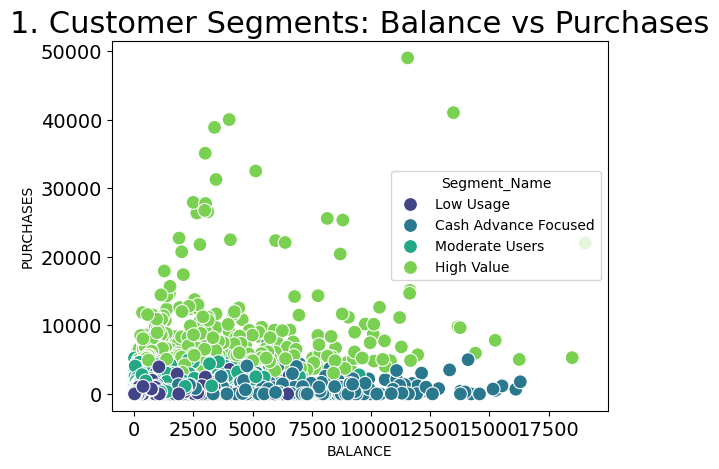

In [44]:
plt.subplot(1, 1, 1)
sns.scatterplot(data=df, x='BALANCE', y='PURCHASES', hue='Segment_Name', palette='viridis', s=100)
plt.title('1. Customer Segments: Balance vs Purchases', fontsize=22) # Increased font
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Low Usage'),
  Text(1, 0, 'Moderate Users'),
  Text(2, 0, 'Cash Advance Focused'),
  Text(3, 0, 'High Value')])

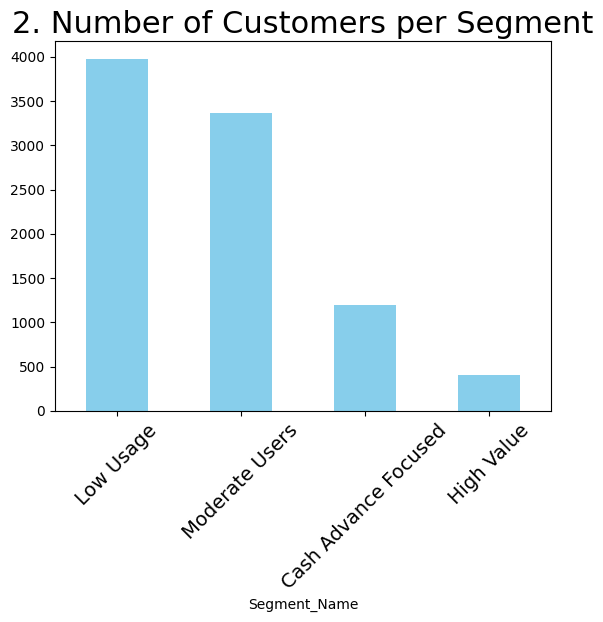

In [45]:
plt.subplot(1,1,1)
df['Segment_Name'].value_counts().plot(kind='bar', color='skyblue')
plt.title('2. Number of Customers per Segment', fontsize=22)
plt.xticks(rotation=45, fontsize=14)

C:\Users\Testing\AppData\Local\Temp\ipykernel_8776\2249190366.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Segment_Name', y='PURCHASES', palette='magma')


([0, 1, 2, 3],
 [Text(0, 0, 'Low Usage'),
  Text(1, 0, 'Cash Advance Focused'),
  Text(2, 0, 'Moderate Users'),
  Text(3, 0, 'High Value')])

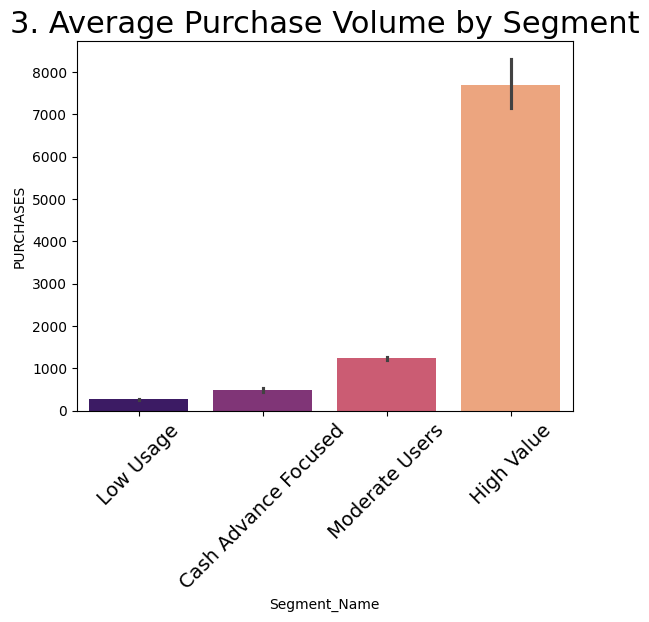

In [46]:
plt.subplot(1,1,1)
sns.barplot(data=df, x='Segment_Name', y='PURCHASES', palette='magma')
plt.title('3. Average Purchase Volume by Segment', fontsize=22)
plt.xticks(rotation=45, fontsize=14)

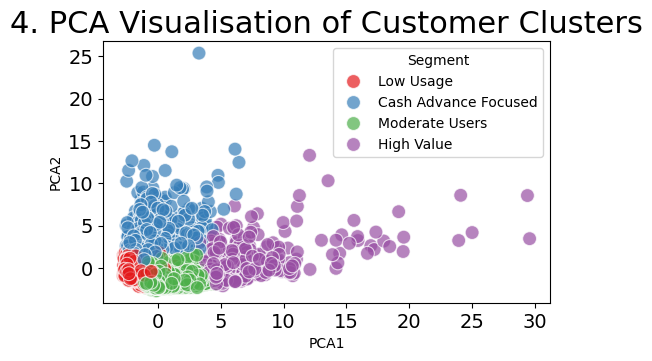

In [47]:
plt.subplot(1,1,1)
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Segment', palette='Set1', s=100, alpha=0.7)
plt.title('4. PCA Visualisation of Customer Clusters', fontsize=22)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


plt.tight_layout(pad=5.0) 
plt.show()

In [48]:
df.to_csv('final_credit_card_segments.csv', index=False)
print("Analysis Complete. 'final_credit_card_segments.csv' has been generated.")

Analysis Complete. 'final_credit_card_segments.csv' has been generated.
